In [1]:
#import of libraries and setup of pandas' configuration
#data manipulation
import pandas as pd
import numpy as np

#graph visualisation
import matplotlib.pyplot as plt
import matplotlib.cm as cm

#export and manage of file
import joblib
import json

#------Machine Learning------
#module validation and split of data
from sklearn.model_selection import KFold, cross_val_score,cross_validate
#import of algorithm
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import (GradientBoostingRegressor,HistGradientBoostingRegressor, RandomForestRegressor)
#metrics
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
#module for data transformation and pipeline creation
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline


#------Setup pandas--------
pd.set_option("display.width", 10000)
pd.set_option("display.max_columns", 14)

print("libreries imported")

libreries imported


In [2]:
#upload dataset
#reading the ods file
datafile = pd.read_excel("test.ods",engine="odf", sheet_name='forward')

#column of measurement of effective movement
eff_move=[1,2,3,4,5,6,7,8,9,10]

#dirty data become Nan
datafile[eff_move]=datafile[eff_move].apply(pd.to_numeric,errors="coerce")

#calculation of physical move
#mean of the 10 column of effective movement
datafile["eff_mean"]= datafile[eff_move].mean(axis=1)
#calculation of standard deviation
datafile["std"]=datafile[eff_move].std(axis=1)
#calculation of theorical error
datafile["th_err"]= datafile["eff_mean"]- datafile["th_move"]

#delete of empty row or Nan row
datafile = datafile.dropna(subset=["time", "power","th_err","std"])
#preview of some data
datafile[["time","power","th_move","eff_mean","std","th_err"]].head()

,time,power,th_move,eff_mean,std,th_err
0,100.0,0.1,0.1,0.220,0.070711,0.120
1,200.0,0.1,0.2,0.341,0.077667,0.141
2,300.0,0.1,0.3,0.426,0.207750,0.126
3,400.0,0.1,0.4,0.700,0.142906,0.300
4,500.0,0.1,0.5,0.692,0.056135,0.192


In [3]:
#Variable exctraction
#x: features in input(tempo,potenza)
x=datafile[["time", "power"]].values
#y_err:main target(prediction of error
y_err=datafile["th_err"].values
#y_std:secondary target(standard deviation)
y_std=datafile["std"].values

#variable to detect the best degree and model
best_degree=2
best_r2=-np.inf

#K fold Cross-validation with 5 split
kf= KFold(n_splits=5,shuffle=True, random_state=43)

#assesment of the best degree
for degree in [2,3,4,5]:
    #StandardScaler: normalizing data
    #PolynomialFeatures: create non linear combination
    #LinearRegression: calculate final weight
    model=make_pipeline(StandardScaler(),PolynomialFeatures(degree=degree), LinearRegression())

    #assesment of the stability of the error model and calculate the R2 value
    scores = cross_val_score(model, x, y_err,cv=kf,scoring="r2")
    mean_r2=np.mean(scores)

    print(f"degree{degree} -> mean R2(cross_validation):{mean_r2:.4f}")

    if mean_r2 >best_r2:
        best_r2=mean_r2
        best_degree=degree

print(f"\nbest degree ->{best_degree}")

degree2 -> mean R2(cross_validation):0.9481
degree3 -> mean R2(cross_validation):0.9515
degree4 -> mean R2(cross_validation):0.9628
degree5 -> mean R2(cross_validation):0.9516

best degree ->4


In [4]:
#training of error model and std model
#training error model
model_err=make_pipeline(StandardScaler(),PolynomialFeatures(degree=best_degree), LinearRegression())
model_err.fit(x, y_err)
#training std model
model_std=make_pipeline(StandardScaler(),PolynomialFeatures(degree=best_degree), LinearRegression())
model_std.fit(x, y_std)

#metric calculation
y_err_pred=model_err.predict(x)
y_std_pred=model_std.predict(x)

print(f"\n error metrics")
#error metrics
print(f"R2: {r2_score(y_err,y_err_pred):.4f}")
print(f"MAE: {mean_absolute_error(y_err,y_err_pred):.4f} m")
print(f"RMSE: {np.sqrt(mean_squared_error(y_err,y_err_pred)):.4f} m")

print(f"\n std metrics")
#std metrics
print(f"R2: {r2_score(y_std,y_std_pred):.4f}")
print(f"MAE: {mean_absolute_error(y_std,y_std_pred):.4f} m")


 error metrics
R2: 0.9873
MAE: 0.0441 m
RMSE: 0.0626 m

 std metrics
R2: 0.3941
MAE: 0.0300 m


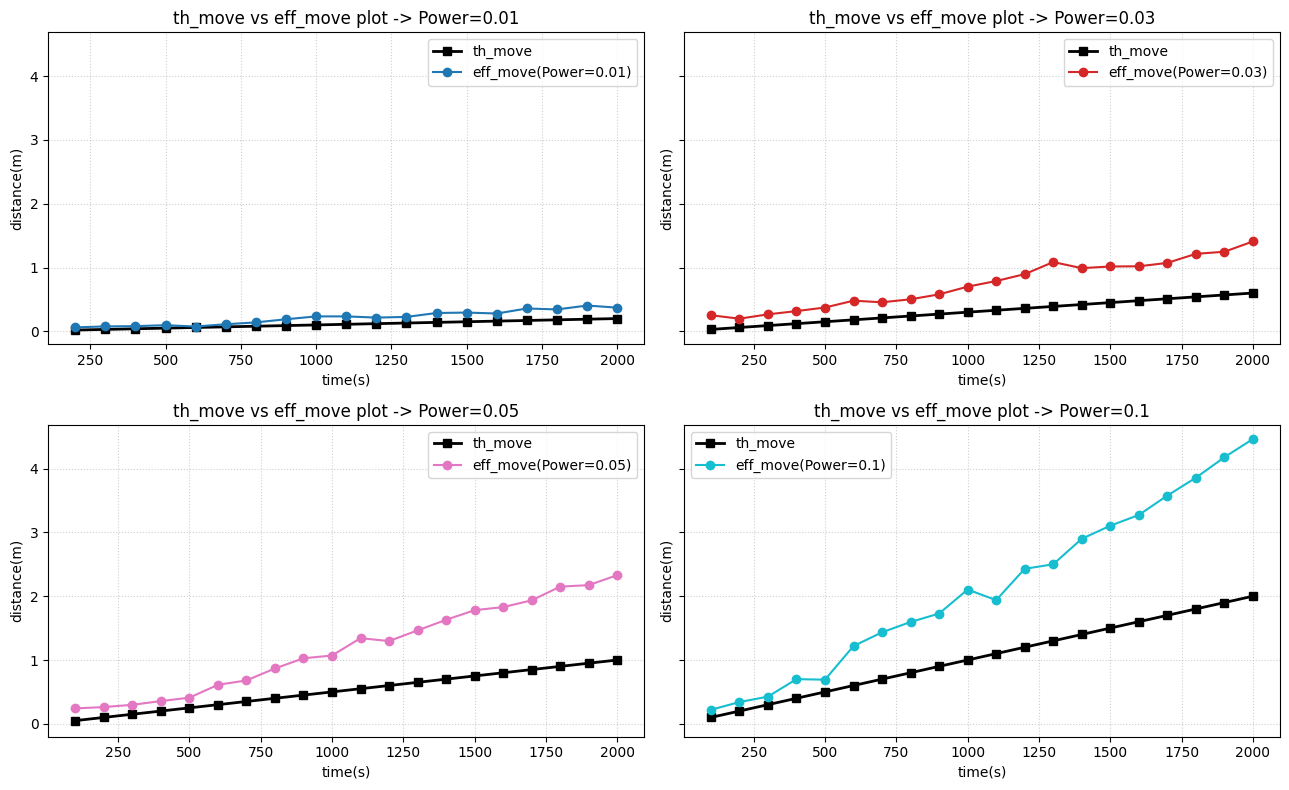

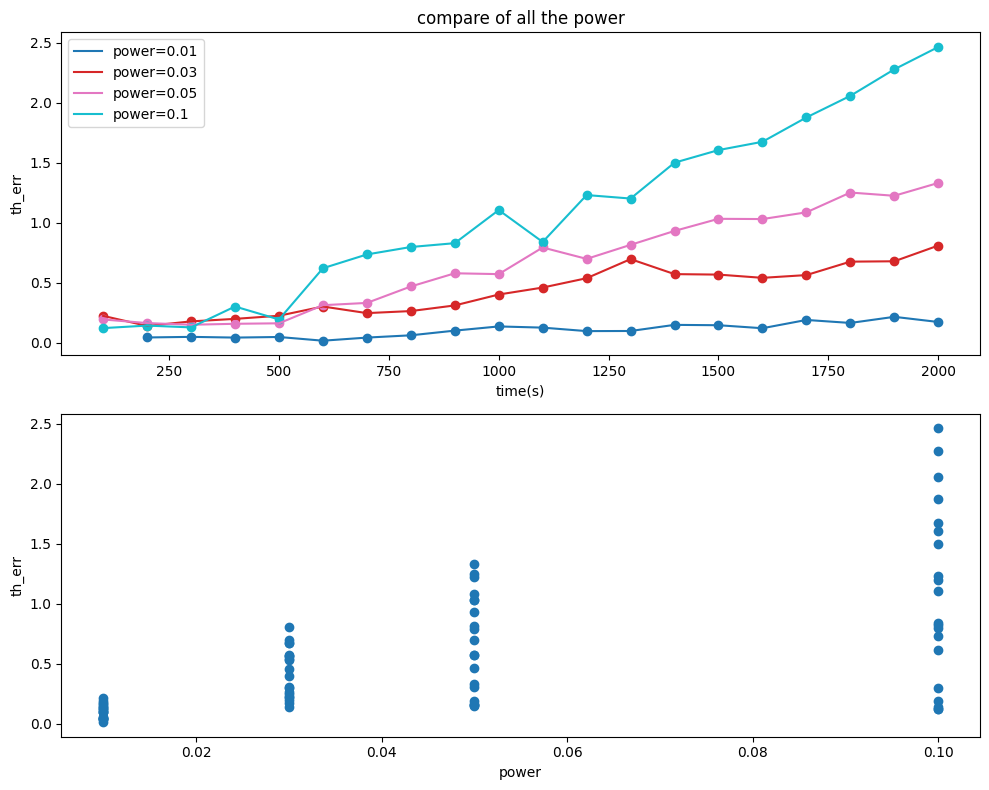

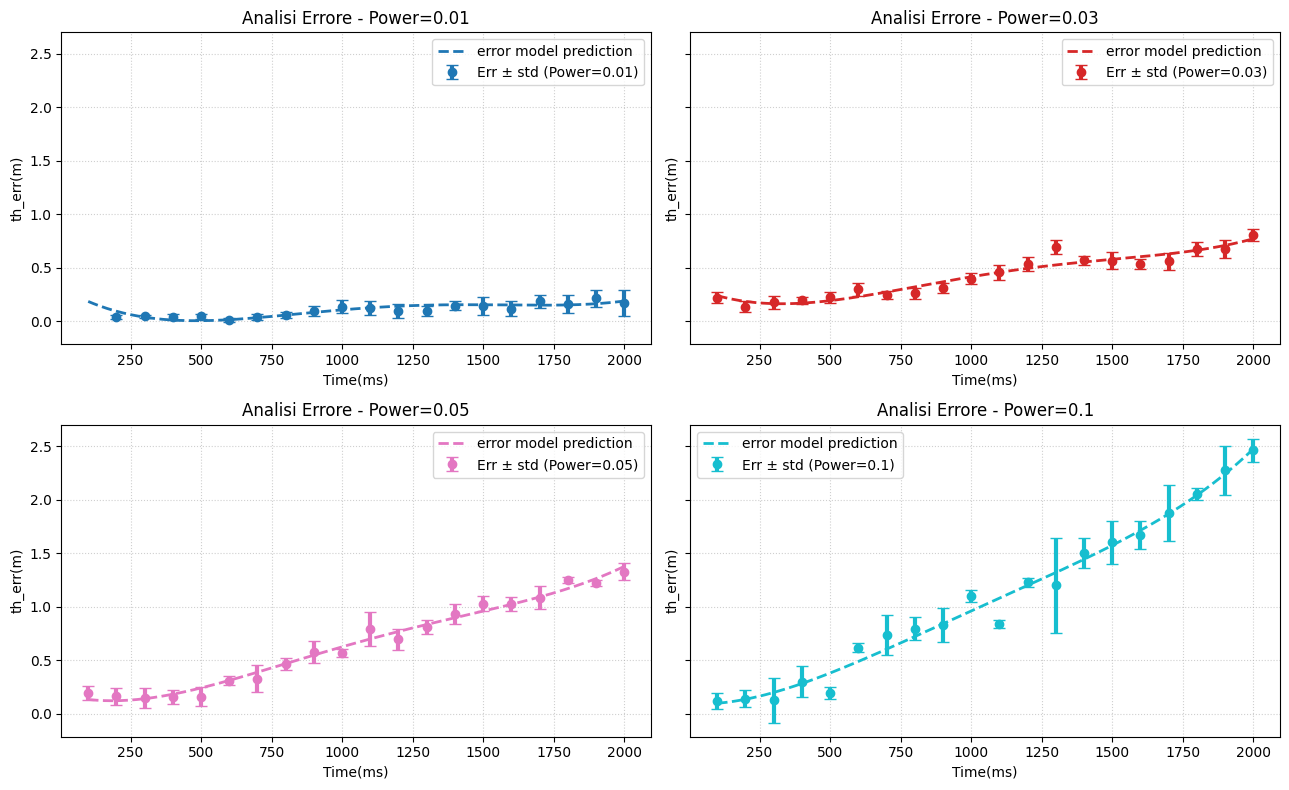

In [5]:
#Graph Visualisation
#Extraction and sort of different powers
powervalues= np.sort(datafile["power"].unique())
n_powers = len(powervalues)

#creation of a color palette
colors = cm.tab10(np.linspace(0,1,len(powervalues)))

cols=2
rows = (n_powers+1) // 2
timerange=np.linspace(datafile["time"].min(), datafile["time"].max(),200)

#th_move vs eff_move plot for different powers
fig, axes =plt.subplots(rows,cols,figsize=(13,4*rows),sharey=True)
axes= np.array(axes).flatten()

for ax, powerval, color in zip(axes,powervalues,colors):
    subset=datafile[datafile["power"]==powerval].sort_values("time")

    ax.plot(subset["time"],subset["th_move"], color="black",linewidth=2,marker="s",linestyle="-",label="th_move")
    ax.plot(subset["time"],subset["eff_mean"], "o-", color=color, linewidth=1.5,label=f"eff_move(Power={powerval})")

    ax.set_xlabel("time(s)")
    ax.set_ylabel("distance(m)")
    ax.set_title(f"th_move vs eff_move plot -> Power={powerval}")
    ax.grid(True, linestyle=":", alpha=0.6)
    ax.legend()

for i in range (n_powers,len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

#Errors for power plot
fig2, (ax1,ax2) = plt.subplots(2,1, figsize=(10,8))

for powerval, color in zip(powervalues, colors):
    subset=datafile[datafile["power"]==powerval].sort_values("time")
    ax1.scatter(subset["time"], subset["th_err"], color= color)
    ax1.plot(subset["time"],subset["th_err"],color=color,label=(f"power={powerval}"))
    
ax1.set_xlabel("time(s)")
ax1.set_ylabel("th_err")
ax1.set_title(f"compare of all the power")
ax1.legend()

ax2.scatter(datafile["power"],datafile["th_err"])
ax2.set_xlabel("power")
ax2.set_ylabel("th_err")
plt.tight_layout()
plt.show()

#Error analysis +- dev stdwith fitted curve
fig3, axes3=plt.subplots(rows,cols,figsize=(13,4*rows),sharey=True)
axes3=np.array(axes3).flatten()

for ax, powerval,color in zip(axes3,powervalues,colors):
    subset=datafile[datafile["power"]==powerval].sort_values("time")
    #real data with their error bar
    ax.errorbar(subset["time"],subset["th_err"],yerr=subset["std"],fmt='o', color=color,ecolor=color,capsize=4,elinewidth=3,label=f"Err ± std (Power={powerval})")
    #creation of simulated data for the curve
    x_curve=np.column_stack([timerange, np.full_like(timerange,powerval)])
    #prediction of the curve
    y_curve_err=model_err.predict(x_curve)
    #track the prediction curve
    ax.plot(timerange,y_curve_err, color=color, linewidth=2, linestyle="--", label="error model prediction")
    ax.set_xlabel("Time(ms)")
    ax.set_ylabel("th_err(m)")
    ax.set_title(f"Analisi Errore - Power={powerval}")
    ax.grid(True,linestyle=":",alpha=0.6)
    ax.legend()

for i in range (n_powers,len(axes3)):
    fig3.delaxes(axes3[i])

plt.tight_layout()
plt.show()

In [6]:
#calulation of metrics to be sure that i chose the right model
pd.set_option("display.width", 10000)
pd.set_option("display.max_columns", 14)

#data upload
datafile = pd.read_excel("test.ods",engine="odf", sheet_name='forward')
eff_move=[1,2,3,4,5,6,7,8,9,10]

#th_err calculation
datafile["th_err"]= datafile[eff_move].mean(axis=1)-datafile["th_move"]
#cleaning of the data
datafile = datafile.dropna(subset=["time", "power","th_err"])
#preparation of x and y
x_orig=datafile[["time", "power"]].values
y=datafile["th_err"].values
#setup of cross validation
kf=KFold(n_splits=5,shuffle=True, random_state=43)
#inizialization of models
LR = LinearRegression()
HGBR=HistGradientBoostingRegressor(random_state=43)
GBR=GradientBoostingRegressor(random_state=43)
RFR=RandomForestRegressor(n_jobs=-1,random_state=43)
#variable to track the best model
bestr2=-9999
bestmodel=None
best_mae=0
best_rmse=0

summary_list=[]
#metrics for the calculation
scoring = {
    'r2': 'r2',
    'mae': 'neg_mean_absolute_error',
    'rmse': 'neg_root_mean_squared_error'}

#compare of the different models
for model in [LR,GBR,HGBR,RFR]:
    scores= cross_validate(model,x_orig,y,cv=kf,scoring=scoring)
    mean_r2= np.mean(scores['test_r2'])
    mean_mae= -np.mean(scores['test_mae'])
    mean_rmse= -np.mean(scores['test_rmse'])
    
    model_name=model.__class__.__name__
    summary_list.append({"Model": model_name, "R2": mean_r2,"MAE":mean_mae, "RMSE":mean_rmse})

    if mean_r2>bestr2:
        bestr2 = mean_r2
        bestmodel= model_name
        best_mae=mean_mae
        best_rmse=mean_rmse

df_summary=pd.DataFrame(summary_list).sort_values(by="R2",ascending=False)
print("Compare of all model")
print(df_summary.to_string(index=False))
print("\n")
print("best model: ", bestmodel)
print("R2: ", bestr2)
print("MAE: ", best_mae)
print("RMSE: ", best_rmse)

Compare of all model
                        Model       R2      MAE     RMSE
        RandomForestRegressor 0.938141 0.078847 0.115788
    GradientBoostingRegressor 0.919247 0.078927 0.111432
HistGradientBoostingRegressor 0.538444 0.229889 0.296822
             LinearRegression 0.496099 0.218773 0.287538


best model:  RandomForestRegressor
R2:  0.9381406905387175
MAE:  0.0788472499999999
RMSE:  0.11578805330600024


In [7]:
#this part is needed to export the result of the model
#exctraction of pipeline component
scaler= model_err.named_steps['standardscaler']
poly=model_err.named_steps['polynomialfeatures']
lr=model_err.named_steps['linearregression']
#save of the pipeline component
joblib.dump(model_err,"model_err_pipeline.joblib")

#EXTRACTION THE MATHEMATICAL PARAMETER FOR KOTLIN
#exctraction of the intercept and coefficients
intercept=float(lr.intercept_)
coefficients=lr.coef_.tolist()
#extraction of power matrix
powers= poly.powers_.tolist()

#exctraction of the parameter from the scaler
scaler_mean=scaler.mean_.tolist()
scaler_scale=scaler.scale_.tolist()

#creation the "dictionary" for kotlin
export_data={"model_type": "PolynomialRegression_Scaled", "degree": int(poly.degree), "features":["time","power"],"scaler_mean":scaler_mean,
             "scaler_scale":scaler_scale,"intercept":intercept,"coefficients":coefficients, "powers": powers}

#EXPORT TO JSON FILE

json_filename="model_coefficient.json"
#write the parameters dictionary into a json file with 4 space indentation
with open(json_filename,"w") as f:
    json.dump(export_data, f, indent=4)

print(f"file exported with success in json: '{json_filename}'\n")

print("\n PRE VIEW OF JSON FILE STRUCTURE")
print(json.dumps(export_data, indent=4))

print("\n MATH EQUATION")

#initialize the equation term list starting with the formatted intercept
terms=[f"{intercept:.6f}"]

#iterate simultaneously through each coefficient and its corresponding exponent pair
for coef, p in zip(coefficients,powers):
    #ignore near zero coefficients for cleaner representation
    if abs(coef)> 1e-8:
        t_exp, p_exp=p[0],p[1]

        #format the numerical coefficient with its sign and 6 decimal places 
        term_str=f"{coef:+.6f}"

        #append 'time' feature string if its exponent is greater than 0
        if t_exp==1:
            term_str +=" * t_sc"
        elif t_exp >1:
            term_str +=f" * t_sc^{t_exp}"

        #append 'power' feature string if its exponent is greater than 0
        if p_exp==1:
            term_str +=" * p_sc"
        elif p_exp>1:
            term_str +=f" * p_sc^{p_exp}"

        terms.append(term_str)
#join all equation terms into a single formatted string
equation="th_err=" + " ".join(terms)

#print the readable algebraic formula
print(equation)

file exported with success in json: 'model_coefficient.json'


 PRE VIEW OF JSON FILE STRUCTURE
{
    "model_type": "PolynomialRegression_Scaled",
    "degree": 4,
    "features": [
        "time",
        "power"
    ],
    "scaler_mean": [
        1062.0253164556962,
        0.04797468354430379
    ],
    "scaler_scale": [
        570.210664483507,
        0.03338990019491579
    ],
    "intercept": 0.6532422943375639,
    "coefficients": [
        0.0,
        0.3991335529450317,
        0.3202421396594269,
        -0.06918277259437422,
        0.31388489267811925,
        -0.12432110482269873,
        -0.015363534935073128,
        0.021988416821340492,
        -0.005668244398307598,
        0.023842112940146556,
        0.036059999190256126,
        0.01947912029217047,
        0.013030916145964466,
        -0.05142730871067072,
        0.015963068090452837
    ],
    "powers": [
        [
            0,
            0
        ],
        [
            1,
            0
        ],
  